# rCM3 UM ancil workflow

A notebook to document and check the outputs of various tasks required to generate a set of UM land ancilliaries that are consistent with a MOM6 land-sea mask.

This also serves as a guide to an rCM3 user who is unfamiliar with using the UM atmospheric model and the creation of all the required inputs for the atmosphere and land-surface model (JULES) currently used by rCM3.

It also helps breakdown the (complicated) ancillary workflow and helps debug future applications in more complex domains.

In time, rCM3 will have the ability to use the CABLE land-surface model as well.

### This notebook is best run in parallel with the rCM3-ancil-suite default suite running in parallel, and manually stepping through each task

That's because some of the files presented here are temporary files that get renamed and/or removed as the suite progresses.

This notebook assumes you have run through all the `rose/cylc` tutorials and you are comfortable manually releasing and triggering tasks.

To begin, launch the suite with `rose suite-run -- --hold` and manually release the `INSTALL COLD`, `ANCIL` and `ANCIL_ANTS` tasks. When complete, launch the top-level suite in the coupled resolution domain, which in the Lismore example is `Lismore-50x50_d1100_ancil_top`

<img src="trigger-ancil-top.png">

### Step 1. Install the grid definition namelists.

Running the task `<Region>_<Resolution>_ancil_top` installs the following files:

- `vertlevs.nl`
- `grid.nl`
- `L70_80km`
- `grid_eg.nl`
  
This task is run in both the outer and inner (coupled) resolutions.

Note : For the coupled resolution, to align the orography grid with the corners of the land-sea mask, you have to specify the bottom left corner in the rose-suite.conf as `<lower_latitidue>-<grid_delta>/2`, `<lower_longitude>-<grid_delta>/2.`

From the rose-suite.info metadata:
```
jinja2:suite.rc=rg01_rs02_blc]
ns=jinja2:suite.rc/rg01/rs02
sort-key=rg01_rs02-d1
title=rg01_rs02_blc
description=Bottom Left corner (lat, lon) of ENDGame domain [Lon: 0-360]
help=The bottom left corner of the domian. If the domain
    =is rotated then this must be given in the
    =rotated coordinates. Note that this is the ENDGame grid
    =and is therefore offset by half a grid spacing from the
    =corner calculated from the centre and the grid size,
    =where centre refers to the centre given when
    =rg01_use_centre is true.
```
In this example, specifying
```
rg01_rs02_blc=-31.295,150.645
rg01_rs02_delta=0.11,0.11
```
generates the following in <Region>_<Resolution>_ancil_top are
```
    DEL_Y="0.11"
    DEL_X="0.11"
    FIRST_LAT="-31.24"
    FIRST_LON="150.7"
    EG_FIRST_LAT="-31.295"
    EG_FIRST_LON="150.645"
    NPTS_Y="50"
    NPTS_X="50"
```
These values are computed using the following cylc logic in the suite-runtime/master.rc file:
```
            FIRST_LAT = {{resln["corner"]["ND"][0]}}
            FIRST_LON = {{resln["corner"]["ND"][1]}}
            EG_FIRST_LAT = {{resln["corner"]["EG"][0]}}
            EG_FIRST_LON = {{resln["corner"]["EG"][1]}}
```
So the contents of grid.nl are now correct:
```
$ more grid.nl 
&grid
delta_lambda_targ=0.11,
delta_phi_targ=0.11,
global=.false.,
igrid_targ=6,
inwsw=1,
lambda_origin_targ=150.755,
lambda_pole=180.0,
phi_origin_targ=-31.185,
phi_pole=90.0,
points_lambda_targ=50,
points_phi_targ=50,
rotated=.false.,
```

### Step 2. Regrid the MOM6 mask.

The rose/cylc task `regrid_mom_mask` uses the MOM6 grids located in the `MOM_INPUT_DIR` directory and will generate a UM land-binary mask ancillary at the (uniform) resolution specified by `rg01_rs02_delta` and `rg01_rs02_npts` in `rose-suite.conf`.

This task produces :

- `qrparm.mask` (Binary land-sea mask in UM ancillary binary format)
- `qrparm.mask.nc` (as above, but in netCDF format)
- `qrparm.landfrac` (Land fraction sea mask in UM ancillary binary format)
- `qrparm.landfrac.nc` (as above, but in netCDF format)

NOTE : As of August 24th 2026, the regridding task has been split into two tasks : `regrid_mom_mask` and `save_mask` due to the NRI `ants` python environment lacking `xarray` support. Hence, the binary masks are saved seperately in the `save_mask` task which only runs in the `ants` environment. 

What is `ants` you ask? The UKMO python package to create land surface ancillary files. See here : https://github.com/MetOffice/ANTS

Let's examine our regridded UM mask in netCDF format.

In [23]:
from pathlib import Path
import iris
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="xarray")
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import Image, display

In [22]:
# Insert your own ANCIL_DIR path here
ANCIL_DIR=Path('/home/548/pag548/cylc-run/rCM3-ancil-suite/share/data/ancils/Lismore-50x50/d1100')

In [36]:
lsm, = iris.load( ANCIL_DIR / 'qrparm.mask')

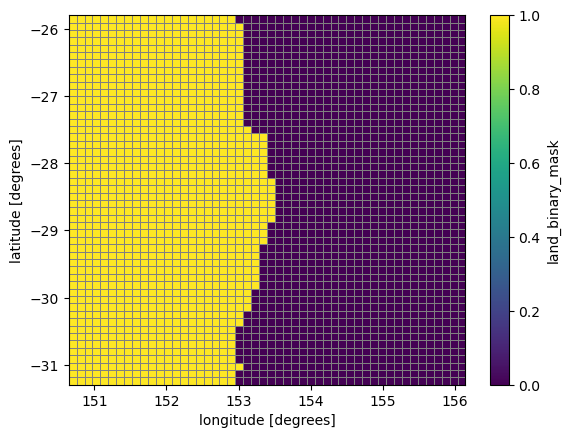

In [37]:
xr.DataArray.from_iris(lsm).plot(edgecolor='grey',linewidth=0.5)

Check the definitions of lat/lon of the mask.

In [38]:
lsm.coord('longitude').points

array([150.7    , 150.81   , 150.92   , 151.03   , 151.14   , 151.25   ,
       151.36   , 151.47   , 151.58   , 151.69   , 151.8    , 151.91   ,
       152.02   , 152.12999, 152.23999, 152.34999, 152.45999, 152.56999,
       152.68   , 152.79   , 152.9    , 153.01   , 153.12   , 153.23   ,
       153.34   , 153.45   , 153.56   , 153.67   , 153.78   , 153.89   ,
       154.     , 154.11   , 154.22   , 154.33   , 154.44   , 154.55   ,
       154.66   , 154.77   , 154.87999, 154.98999, 155.09999, 155.20999,
       155.31999, 155.43   , 155.54   , 155.65   , 155.76   , 155.87   ,
       155.98   , 156.09   ], dtype=float32)

In [39]:
lsm.coord('latitude').points

array([-31.24    , -31.13    , -31.02    , -30.91    , -30.8     ,
       -30.69    , -30.58    , -30.47    , -30.36    , -30.25    ,
       -30.14    , -30.029999, -29.92    , -29.81    , -29.7     ,
       -29.59    , -29.48    , -29.369999, -29.26    , -29.15    ,
       -29.039999, -28.93    , -28.82    , -28.71    , -28.6     ,
       -28.49    , -28.38    , -28.27    , -28.16    , -28.05    ,
       -27.94    , -27.83    , -27.72    , -27.61    , -27.5     ,
       -27.39    , -27.279999, -27.17    , -27.06    , -26.95    ,
       -26.84    , -26.73    , -26.619999, -26.51    , -26.4     ,
       -26.29    , -26.18    , -26.07    , -25.96    , -25.85    ],
      dtype=float32)

In [40]:
lsm.data.dtype

dtype('int64')

Let's compare it against the target MOM6 mask, which in this case was double the resolution (100x100)

In [24]:
# Insert your own MOM6_DIR here
MOM6_DIR = Path('/g/data/gb02/pag548/rom3-inputdirs/rCM3-Lismore-demo-100x100/')
fr_mesh = xr.load_dataset( MOM6_DIR / 'access-rom3-ESMFmesh.nc')
fr_hgrid = xr.load_dataset( MOM6_DIR / 'hgrid.nc')

In [42]:
geo_lon_t = fr_hgrid.x[1::2,1::2]
geo_lat_t = fr_hgrid.y[1::2,1::2]

lons = geo_lon_t.values[0,:]
lats = geo_lat_t.values[:,0]

nx = len(lons)
ny = len(lats)

fr_mom_da = xr.DataArray(fr_mesh.elementMask.values.reshape(ny,nx),
                        dims=['lat','lon'],
                        coords={'lat':lats, 
                                'lon':lons})

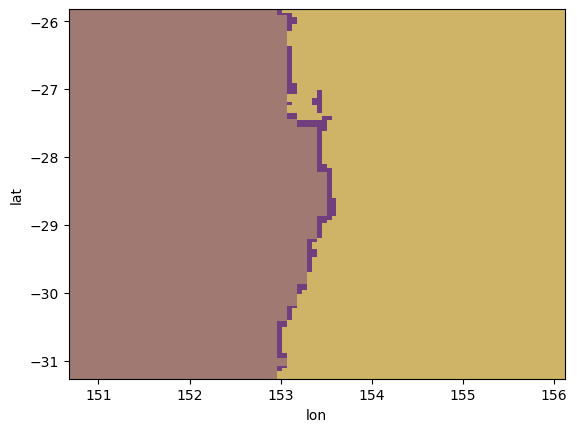

In [44]:
fig,ax=plt.subplots()
xr.DataArray.from_iris(lsm).plot(ax=ax,alpha=0.5,add_colorbar=False)
fr_mom_da.plot(ax=ax,alpha=0.5,add_colorbar=False)

Our UM mask neatly lies inside the purple MOM6 mask.

### Step 3. Generate the vegetation ancillaries consistent with the above mask.

Next we generate the vegetation ancillaries that are consistent with our land-sea mask. This is actually a three step process done across three separate tasks. 

The first task is `<Region>_<Resolution>_ancil_lct`. Trigger this now.

<img src="trigger-ancil-lct.png">

This task generates the following files:

- `qrparm.veg.frac_cci_pre_c4` (9 level vegetation grids in UM ancillary binary format)
- `qrparm.veg.frac_cci_pre_c4.nc` (as above, but in netCDF format)

It also renames our original land-sea mask `qrparm.mask` to `qrparm.mask_cci` and then generates a symbolic link to the renamed file. This is done to track providence of the mask generation (i.e. using CCI datasets)

In [26]:
veg_frac_pre_c4, = iris.load( ANCIL_DIR / 'qrparm.veg.frac_cci_pre_c4')

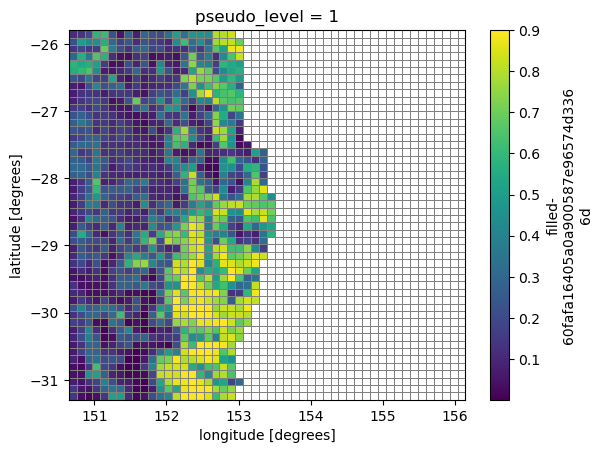

In [34]:
xr.DataArray.from_iris(veg_frac_pre_c4[0]).plot(edgecolor='grey',linewidth=0.5)

Let's check the co-ordinates align with the orignal land-sea mask

In [48]:
veg_frac_pre_c4.coord('longitude').points

array([150.7    , 150.81   , 150.92   , 151.03   , 151.14   , 151.25   ,
       151.36   , 151.47   , 151.58   , 151.69   , 151.8    , 151.91   ,
       152.02   , 152.12999, 152.23999, 152.34999, 152.45999, 152.56999,
       152.68   , 152.79   , 152.9    , 153.01   , 153.12   , 153.23   ,
       153.34   , 153.45   , 153.56   , 153.67   , 153.78   , 153.89   ,
       154.     , 154.11   , 154.22   , 154.33   , 154.44   , 154.55   ,
       154.66   , 154.77   , 154.87999, 154.98999, 155.09999, 155.20999,
       155.31999, 155.43   , 155.54   , 155.65   , 155.76   , 155.87   ,
       155.98   , 156.09   ], dtype=float32)

In [49]:
np.all(veg_frac_pre_c4.coord('longitude').points == lsm.coord('longitude').points)

np.True_

In [50]:
np.all(veg_frac_pre_c4.coord('latitude').points == lsm.coord('latitude').points)

np.True_

### Step 4. Include World Cover data.

Next we modify the vegetation ancillaries to include the lastest 'World Cover' data. This step allows better representation of urban areas. This step uses the task `<Region>_<Resolution>_ancil_lct_postproc_wc_urban`. Trigger this task now, and it will update the files:

- `qrparm.veg.frac_cci_pre_c4`, `qrparm.veg.frac_cci_pre_c4.nc`,

and generate the files
- `qrparm.veg.frac_cci_pre_c4_pre_wc`, `qrparm.veg.frac_cci_pre_c4_pre_wc.nc`

In [54]:
veg_frac_pre_c4_wc, = iris.load( ANCIL_DIR / 'qrparm.veg.frac_cci_pre_c4_pre_wc')

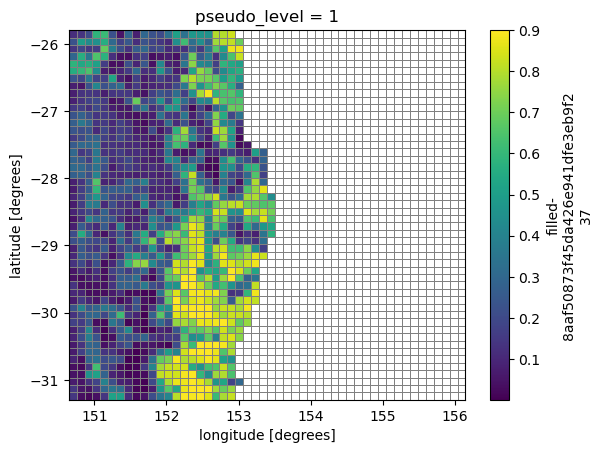

In [55]:
xr.DataArray.from_iris(veg_frac_pre_c4_wc[0]).plot(edgecolor='grey',linewidth=0.5)

In [56]:
np.all(veg_frac_pre_c4.coord('longitude').points == lsm.coord('longitude').points)

np.True_

In [57]:
np.all(veg_frac_pre_c4.coord('latitude').points == lsm.coord('latitude').points)

np.True_

### Step 5. Install C4 land cover data

We then complete the vegetation processing with the task `<Region>_<Resolution>_ancil_lct_postproc_c4`. This injects 'C4' data into the land cover type fraction dataset, and produces the output files:

- `qrparm.veg.frac_cci`, `qrparm.veg.frac_cci.nc`

A symbolic link is created to both of these files which removes the last suffix, i.e.

- `qrparm.veg.frac -> qrparm.veg.frac_cci`
- `qrparm.veg.frac.nc -> qrparm.veg.frac_cci.nc`

In [16]:
veg_frac, = iris.load( ANCIL_DIR / 'qrparm.veg.frac_cci')

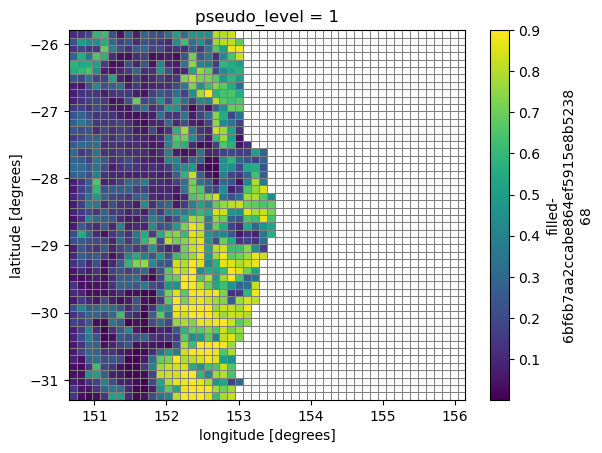

In [17]:
xr.DataArray.from_iris(veg_frac[0]).plot(edgecolor='grey',linewidth=0.5)

In [18]:
np.all(veg_frac.coord('longitude').points == lsm.coord('longitude').points)

np.True_

In [19]:
np.all(veg_frac.coord('latitude').points == lsm.coord('latitude').points)

np.True_

The following flowchart summarises the task flow to generate the vegetation land cover classification ancillaries.

<img src="ancil_lct_flow.png">

We have now run all the major master, 'umbrella' tasks for the ancilliary suite.

<img src="trigger-ancil-c4.png">

Now the final vegetation land cover classification ancillaries have been created, the suite splits and launches many tasks in parallel. Some tasks are grouped into their own subclasses with their own dependencies, such as

- orography
- soil characteristics
- leaf areas and canopy heights
- ice and snow
- moruses

Let's review the orography set of tasks first.

The first orography task is `<Region>_<Resolution>_ancil_cap_orog`. Any tasks that contain `cap` in their task name do not use the python `ants` library. Rather they use the older UM binary. E.g. this task is launched with the command
```
$ more app/ancil_cap_orog/rose-app.conf 
meta=ancilOrog

[command]
default=rose mpi-launch -v central_ancillary.exe
```


### Step 6. Generate orography.

Triggering the task `<Region>_<Resolution>_ancil_cap_orog` will generate the file `qrparm.orog`.

In [58]:
orog = iris.load( ANCIL_DIR / 'qrparm.orog')

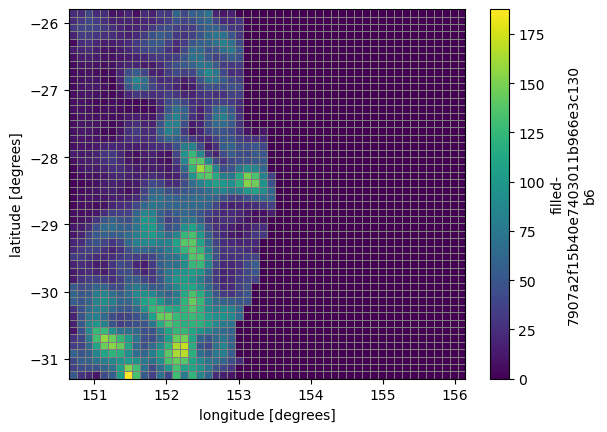

In [59]:
xr.DataArray.from_iris(orog[0]).plot(edgecolor='grey',linewidth=0.5)

The co-ordinates of `qrparm.orog` are produced by an older Fortan CAP exe and are 32-bit co-ordinates by default.

In [60]:
orog[0].coord('longitude').points

array([150.7    , 150.81   , 150.92   , 151.03   , 151.14   , 151.25   ,
       151.36   , 151.47   , 151.58   , 151.69   , 151.8    , 151.91   ,
       152.02   , 152.12999, 152.23999, 152.34999, 152.45999, 152.56999,
       152.68   , 152.79   , 152.9    , 153.01   , 153.12   , 153.23   ,
       153.34   , 153.45   , 153.56   , 153.67   , 153.78   , 153.89   ,
       154.     , 154.11   , 154.22   , 154.33   , 154.44   , 154.55   ,
       154.66   , 154.77   , 154.87999, 154.98999, 155.09999, 155.20999,
       155.31999, 155.43   , 155.54   , 155.65   , 155.76   , 155.87   ,
       155.98   , 156.09   ], dtype=float32)

In [61]:
lsm.coord('longitude').points

array([150.7    , 150.81   , 150.92   , 151.03   , 151.14   , 151.25   ,
       151.36   , 151.47   , 151.58   , 151.69   , 151.8    , 151.91   ,
       152.02   , 152.12999, 152.23999, 152.34999, 152.45999, 152.56999,
       152.68   , 152.79   , 152.9    , 153.01   , 153.12   , 153.23   ,
       153.34   , 153.45   , 153.56   , 153.67   , 153.78   , 153.89   ,
       154.     , 154.11   , 154.22   , 154.33   , 154.44   , 154.55   ,
       154.66   , 154.77   , 154.87999, 154.98999, 155.09999, 155.20999,
       155.31999, 155.43   , 155.54   , 155.65   , 155.76   , 155.87   ,
       155.98   , 156.09   ], dtype=float32)

The next orography task is `<Region>_<Resolution>_ancil_mean_orog`. This is two-step task that firstly
- produces a concatentated SRTM orography file `orog_srtm/SRTM_concat.nc` (which is a global dataset)
- then produces the file `orog_srtm/qrparm.orog.srtm.nc`


In [62]:
orog_srtm=iris.load_cube(ANCIL_DIR / 'orog_srtm/qrparm.orog.srtm.nc')

In [63]:
orog_srtm.coord('longitude').points

array([150.7    , 150.81   , 150.92   , 151.03   , 151.14   , 151.25   ,
       151.36   , 151.47   , 151.58   , 151.69   , 151.8    , 151.91   ,
       152.02   , 152.12999, 152.23999, 152.34999, 152.45999, 152.56999,
       152.68   , 152.79   , 152.9    , 153.01   , 153.12   , 153.23   ,
       153.34   , 153.45   , 153.56   , 153.67   , 153.78   , 153.89   ,
       154.     , 154.11   , 154.22   , 154.33   , 154.44   , 154.55   ,
       154.66   , 154.77   , 154.87999, 154.98999, 155.09999, 155.20999,
       155.31999, 155.43   , 155.54   , 155.65   , 155.76   , 155.87   ,
       155.98   , 156.09   ], dtype=float32)

In [64]:
orog_srtm.coord('longitude').points.dtype

dtype('float32')

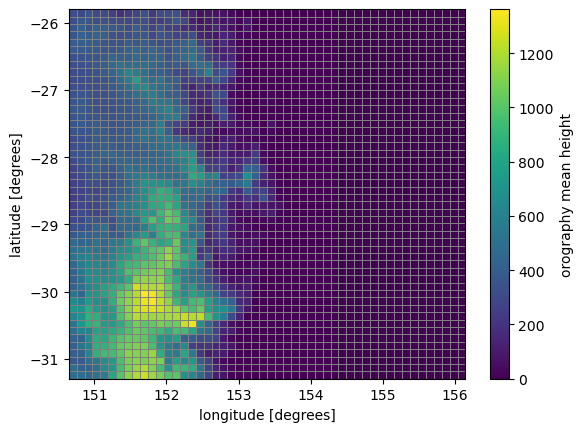

In [65]:
xr.DataArray.from_iris(orog_srtm).plot(edgecolor='grey',linewidth=0.5)

The final orography task is `<Region>_<Resolution>_ancil_mean_orog_smooth`, which smooths the SRTM data according to a variety of algorithms. This produces the folowing files in `./orog_srtm/`:
```
qrparm.orog.srtm.121x1
qrparm.orog.srtm.121x10
qrparm.orog.srtm.121x100
qrparm.orog.srtm.121x20
qrparm.orog.srtm.121x35
qrparm.orog.srtm.121x5
qrparm.orog.srtm.121x50
qrparm.orog.srtm.121x75
```
In the main ancilliary directory, a symbolic link `qrparm.orog.mn` links to `orog_srtm/qrparm.orog.srtm.121x1`

Here is `rose/cylc` task graph with the orography tasks completed.

<img src="trigger-orog.png">

In [66]:
orog_smooth, = iris.load( ANCIL_DIR / 'qrparm.orog.mn')

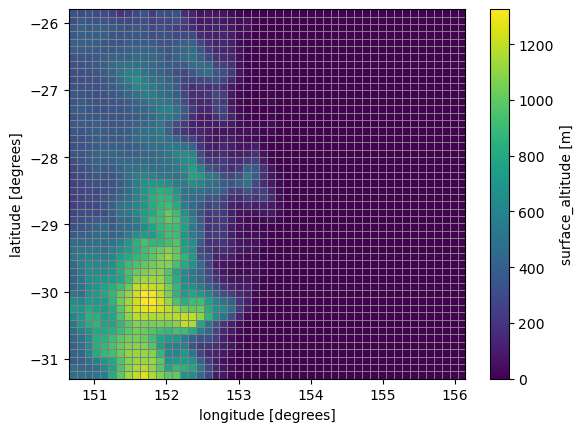

In [67]:
xr.DataArray.from_iris(orog_smooth).plot(edgecolor='grey',linewidth=0.5)

In [68]:
orog_smooth[0].coord('longitude').points

array([150.7    , 150.81   , 150.92   , 151.03   , 151.14   , 151.25   ,
       151.36   , 151.47   , 151.58   , 151.69   , 151.8    , 151.91   ,
       152.02   , 152.12999, 152.23999, 152.34999, 152.45999, 152.56999,
       152.68   , 152.79   , 152.9    , 153.01   , 153.12   , 153.23   ,
       153.34   , 153.45   , 153.56   , 153.67   , 153.78   , 153.89   ,
       154.     , 154.11   , 154.22   , 154.33   , 154.44   , 154.55   ,
       154.66   , 154.76999, 154.87999, 154.98999, 155.09999, 155.20999,
       155.31999, 155.43   , 155.54   , 155.65   , 155.76   , 155.87   ,
       155.98   , 156.09   ], dtype=float32)

The following flowchart describes the task flows for orography related tasks.

<img src="ancil_orog_flow.png">

## Step 7. Process soil characteristics

The next set of multi-step tasks are related to generating soil characteristics. First, we begin with `<Region>_<Resolution>_ancil_soils_hydr`. This reads in the global `soils_hydrology.nc` file, regrids it to our target domain and saves it to `soil_hydrology`

In [70]:
hydro = iris.load(ANCIL_DIR / 'soil_hydrology')

In [71]:
hydro[0].coords('latitude')[0].points

array([-31.24    , -31.13    , -31.02    , -30.91    , -30.8     ,
       -30.69    , -30.58    , -30.47    , -30.36    , -30.25    ,
       -30.14    , -30.029999, -29.92    , -29.81    , -29.7     ,
       -29.59    , -29.48    , -29.369999, -29.26    , -29.15    ,
       -29.039999, -28.93    , -28.82    , -28.71    , -28.6     ,
       -28.49    , -28.38    , -28.27    , -28.16    , -28.05    ,
       -27.94    , -27.83    , -27.72    , -27.61    , -27.5     ,
       -27.39    , -27.279999, -27.17    , -27.06    , -26.95    ,
       -26.84    , -26.73    , -26.619999, -26.51    , -26.4     ,
       -26.29    , -26.18    , -26.07    , -25.96    , -25.85    ],
      dtype=float32)

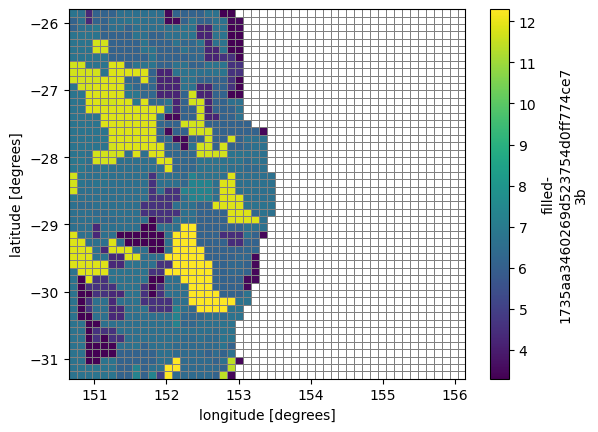

In [72]:
xr.DataArray.from_iris(hydro[0]).plot(edgecolor='grey',linewidth=0.5)

Next we process the soil albedo with the task `<Region>_<Resolution>_ancil_soil_albedo`. This reads in the global dataset `soil_albedo.nc` along with the existing files:
- `soil_hydrology`
- `qrparm.veg.frac.nc`
and outputs `qrparm.soil_cci`

The global albedo dataset may require manual inputs to provide data for small islands. It is defined on 0.05 degree grid.

In [73]:
albedo = xr.open_dataset('/home/548/pag548/cylc-run/rCM3-ancil-suite/share/data/etc/ancil_master_ants/soil_albedo/classic/v3/soil_albedo.nc')

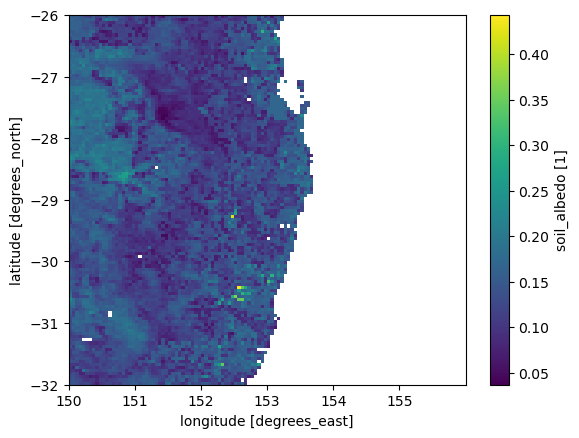

In [74]:
albedo.soil_albedo.sel(latitude=slice(-26,-32),longitude=slice(150,156)).plot()

In [78]:
soil = iris.load( ANCIL_DIR / 'qrparm.soil_cci')

In [79]:
soil[0].coords('latitude')[0].points

array([-31.23999977, -31.12999916, -31.02000046, -30.90999985,
       -30.79999924, -30.69000053, -30.57999992, -30.46999931,
       -30.36000061, -30.25      , -30.13999939, -30.02999878,
       -29.92000008, -29.80999947, -29.70000076, -29.59000015,
       -29.47999954, -29.36999893, -29.26000023, -29.14999962,
       -29.03999901, -28.93000031, -28.81999969, -28.70999908,
       -28.60000038, -28.48999977, -28.37999916, -28.27000046,
       -28.15999985, -28.04999924, -27.94000053, -27.82999992,
       -27.71999931, -27.61000061, -27.5       , -27.38999939,
       -27.27999878, -27.17000008, -27.05999947, -26.95000076,
       -26.84000015, -26.72999954, -26.61999893, -26.51000023,
       -26.39999962, -26.29000092, -26.18000031, -26.06999969,
       -25.95999908, -25.85000038], dtype='>f8')

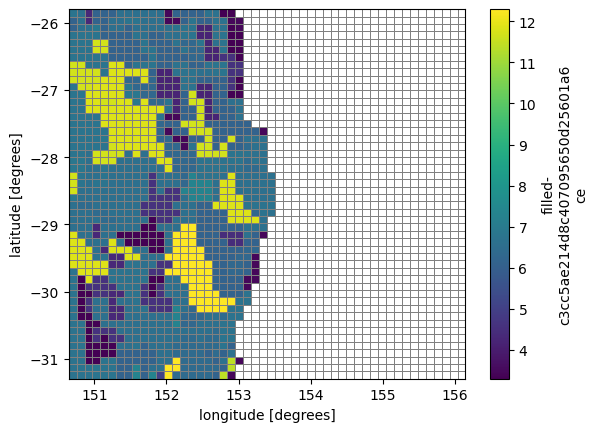

In [80]:
xr.DataArray.from_iris(soil[0]).plot(edgecolor='grey',linewidth=0.5)

The last task in this dependency is `<Region>_<Resolution>_ancil_soil_dust`. This processes the `qrparm.soil_cci` and `qrparm.veg.frac` ancillary files and generates the ancillary `qrparm.soil.dust`

In [81]:
dust = iris.load( ANCIL_DIR / 'qrparm.soil.dust')

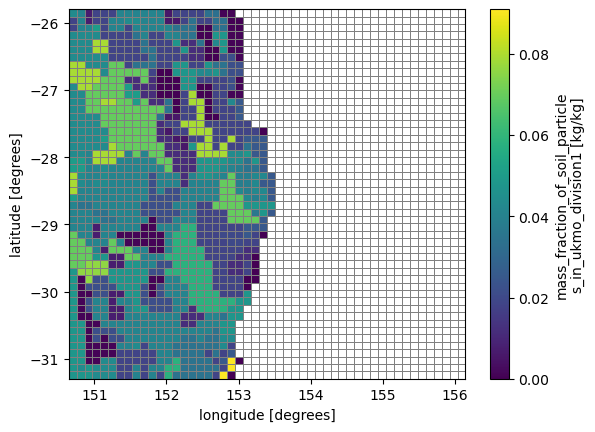

In [82]:
xr.DataArray.from_iris(dust[0]).plot(edgecolor='grey',linewidth=0.5)

Here is `rose/cylc` task graph with the orography tasks completed.

<img src="trigger-albedo.png">

The flowchart below describes the dependencies of the above soil-related tasks.

<img src="ancil_soil_flow.png">

There are two stand-alone soils tasks.

The first is`<Region>_<Resolution>_ancil_soil_roughness` which uses the existing `qrparm.veg.frac.nc` file along with global MODIS leaf area index data and global soil roughness data to produce `qrparm.soil_roughness`.

In [83]:
rough, = iris.load( ANCIL_DIR / 'qrparm.soil_roughness')

/home/548/pag548/.local/lib/python3.12/site-packages/iris/fileformats/_ff.py:737: _WarnComboLoadingDefaulting: The stash code m01s00i097 is on a grid 0 which has not been explicitly handled by the fieldsfile loader. Assuming the data is on a P grid.
  warnings.warn(


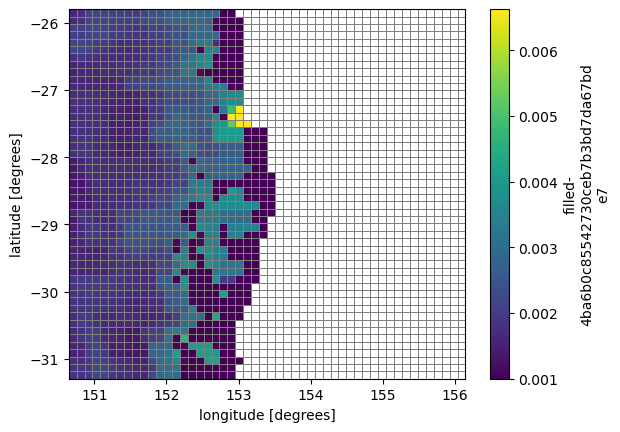

In [84]:
xr.DataArray.from_iris(rough).plot(edgecolor='grey',linewidth=0.5)

The second task is related to soil hydrology and is called`<Region>_<Resolution>_ancil_topographic_index`. It also uses `qrparm.veg.frac.nc` file along with global topographic wetness index data to produce `qrparm.hydtop`.

Here is rose/cylc task graph with the orography tasks completed

<img src="graph-roughness.png">


In [85]:
topo = iris.load( ANCIL_DIR / 'qrparm.hydtop')

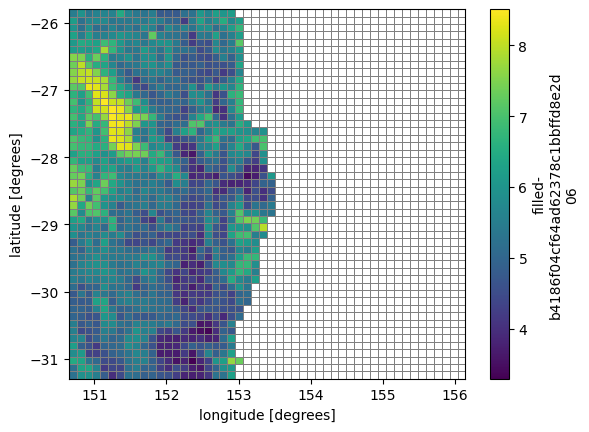

In [86]:
xr.DataArray.from_iris(topo[0]).plot(edgecolor='grey',linewidth=0.5)

## Step 8. Process leaf and canopy data.

We need to populate the vegetation with leaf and canopy data. The first task is `<Region>_<Resolution>_ancil_lai` which processes 'Leaf Area Index' and produces a temporary file `lai`.

In [48]:
lai, = iris.load( ANCIL_DIR / 'lai')

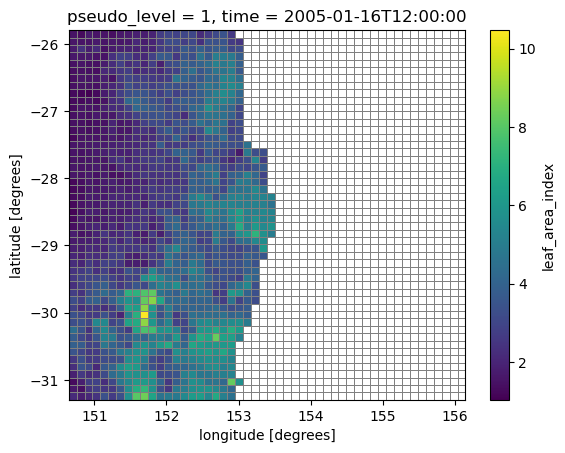

In [49]:
xr.DataArray.from_iris(lai)[0,0].plot(edgecolor='grey',linewidth=0.5)

The next task `<Region>_<Resolution>_ancil_canopy_heights` combines the `lai` ancillary with tree data and canopy height factors and writes the data to `qrparm.veg.func` 

In [50]:
lai_canopy = iris.load( ANCIL_DIR / 'qrparm.veg.func')

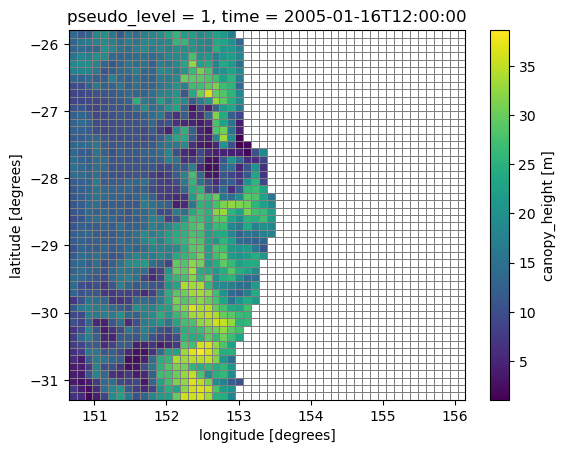

In [51]:
xr.DataArray.from_iris(lai_canopy[0][0,0]).plot(edgecolor='grey',linewidth=0.5)

Here is rose/cylc task graph with leaf and canopy tasks completed

<img src="graph-lai.png">

The flowchart below describes the dependencies of the above soil-related tasks.

<img src="ancil_lai_flow.png">

## Step 9. Process SST/ice and snow

The last multi-step tasks which contain a chain of dependencies begins with  `<Region>_<Resolution>_ancil_cap_vegfrac`. Like the previous `ancil_cap` task, this uses an older FORTRAN binary and is independent of the python-based `ants` workflow.

This task outputs
- `qrparm.veg.func_igbp`
- `qrparm.veg.frac_igbp`
- `qrparm.veg.dist`
- `qrparm.soil.dust_igbp`

And it updates `qrparm.soil`.

In [90]:
veg_frac_igbp, = iris.load( ANCIL_DIR / 'qrparm.veg.frac_igbp')

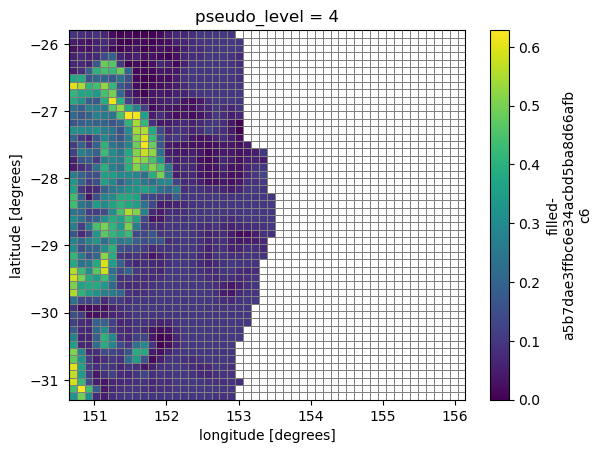

In [91]:
xr.DataArray.from_iris(veg_frac_igbp)[3].plot(edgecolor='grey',linewidth=0.5)

In [92]:
soil_dust = iris.load( ANCIL_DIR / 'qrparm.soil.dust_igbp')

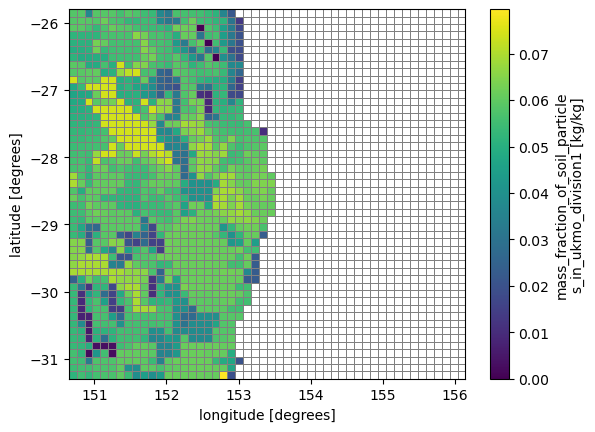

In [93]:
xr.DataArray.from_iris(soil_dust[0]).plot(edgecolor='grey',linewidth=0.5)

In [94]:
soil = iris.load( ANCIL_DIR / 'qrparm.soil')

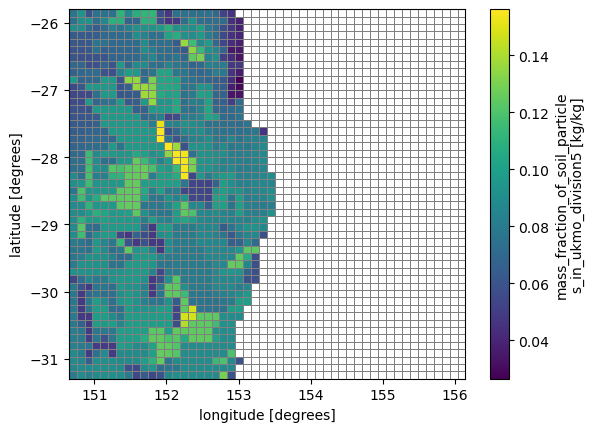

In [95]:
xr.DataArray.from_iris(soil_dust[4]).plot(edgecolor='grey',linewidth=0.5)

There are two tasks downstream of `<Region>_<Resolution>_ancil_cap_vegfrac`. One is `<Region>_<Resolution>_ancil_cap_sstice`. This task processes global climatologies for seaice and SSTs
- `qrclim.sst`
- `qrclim.seaice`

In [62]:
seaice = iris.load( ANCIL_DIR / 'qrclim.seaice')

/jobfs/172902492.gadi-pbs/ipykernel_3151241/979677363.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  xr.DataArray.from_iris(seaice[1][0]).plot(edgecolor='grey',linewidth=0.5)


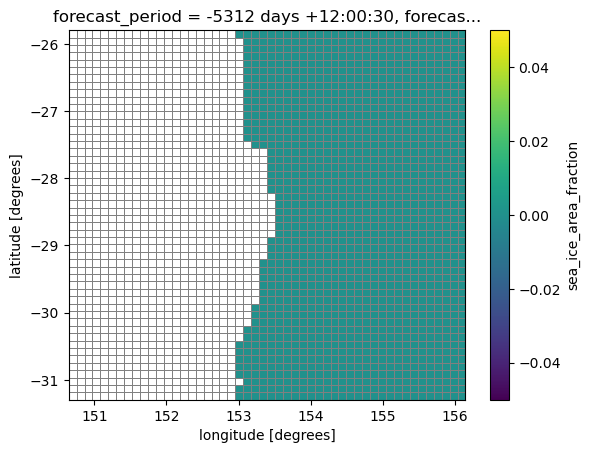

In [63]:
xr.DataArray.from_iris(seaice[1][0]).plot(edgecolor='grey',linewidth=0.5)

In [64]:
sst = iris.load( ANCIL_DIR / 'qrclim.sst')

/jobfs/172902492.gadi-pbs/ipykernel_3151241/1747977962.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  xr.DataArray.from_iris(sst[0][0]).plot(edgecolor='grey',linewidth=0.5)


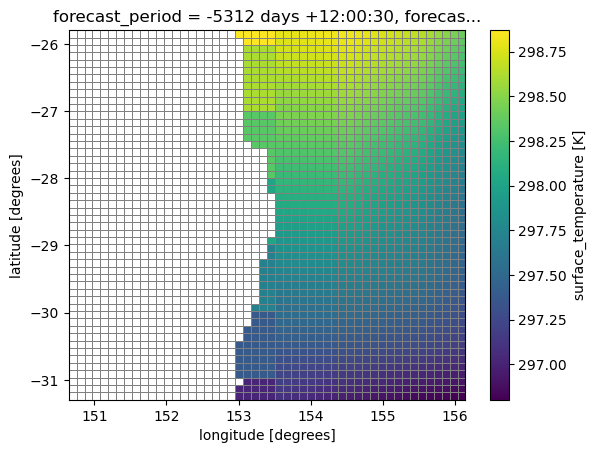

In [65]:
xr.DataArray.from_iris(sst[0][0]).plot(edgecolor='grey',linewidth=0.5)

The other task is `<Region>_<Resolution>_ancil_cap_smcsnow`. This task processes global climatologies for soil moisture content and snow. The output is `qrclim.smow`

In [66]:
smow = iris.load( ANCIL_DIR / 'qrclim.smow')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/iris/fileformats/pp.py:1490: CFWarning: this date/calendar/year zero convention is not supported by CF
  self._t1 = cftime.datetime(
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/iris/fileformats/pp.py:1523: CFWarning: this date/calendar/year zero convention is not supported by CF
  self._t2 = cftime.datetime(


/jobfs/172902492.gadi-pbs/ipykernel_3151241/217714727.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  xr.DataArray.from_iris(smow[6][0]).plot(edgecolor='grey',linewidth=0.5)


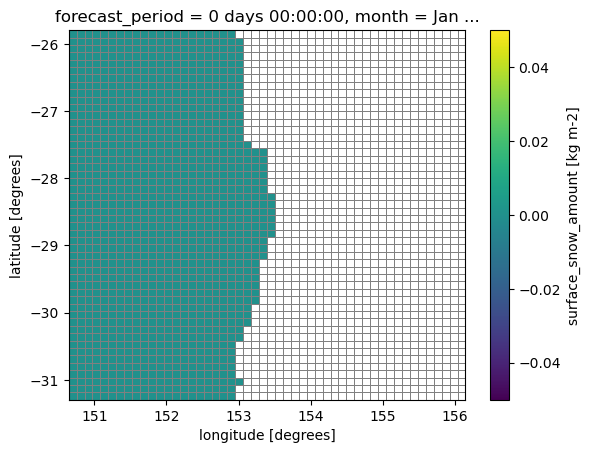

In [67]:
xr.DataArray.from_iris(smow[6][0]).plot(edgecolor='grey',linewidth=0.5)

The flowchart below shows the task dependencies for all `cap` related tasks.

<img src="ancil_cap_flow.png">

And the corresponding `rose/cylc` graph

<img src="graph-cap.png">

## Step 10. Process remaining stand-alone tasks.

The last stand-alone tasks can be divided into three sections. The first is ozone processing:
- `<Region>_<Resolution>_ancil_cap_ozone`

which uses the FORTRAN exectuable. The next group of tasks compute aerosol climatologies as specified in the `suite.rc`
```
{% set AERO_CLIMS = ["biog", "biom", "blck", "dust", "ocff", "sslt", "sulp"] %}
```
- `<Region>_<Resolution>_ancil_ocff`
- `<Region>_<Resolution>_ancil_biog`
- `<Region>_<Resolution>_ancil_biom`
- `<Region>_<Resolution>_ancil_blck`
- `<Region>_<Resolution>_ancil_sslt`
- `<Region>_<Resolution>_ancil_sulp`
- `<Region>_<Resolution>_ancil_dust`

They simply regrid the global climatologies of these quantities onto the local lat/lon grid and the specified vertical levels. They output both UM ancillary format and netCDF files.

These are the remaining tasks that use the python `ants` workflows.
- `<Region>_<Resolution>_ancil_topographic_index`
- `<Region>_<Resolution>_ancil_clim_sea`
- `<Region>_<Resolution>_ancil_lake`

Let's examine the outputs of these tasks.

`<Region>_<Resolution>_ancil_cap_ozone` produces the local ozone climatology `qrclim.ozone.unfix`

In [96]:
ozone, = iris.load( ANCIL_DIR / 'qrclim.ozone.unfix')

/home/548/pag548/.local/lib/python3.12/site-packages/iris/fileformats/_ff.py:737: _WarnComboLoadingDefaulting: The stash code m01s00i060 is on a grid 22 which has not been explicitly handled by the fieldsfile loader. Assuming the data is on a P grid.
  warnings.warn(
/home/548/pag548/.local/lib/python3.12/site-packages/iris/fileformats/rules.py:376: IrisUserWarning: Unable to create instance of HybridPressureFactory. The source data contains no field(s) for 'surface_air_pressure'.
  warnings.warn(


/jobfs/177174656.gadi-pbs/ipykernel_1618406/2504981220.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  xr.DataArray.from_iris(ozone[0]).plot(edgecolor='grey',linewidth=0.5)


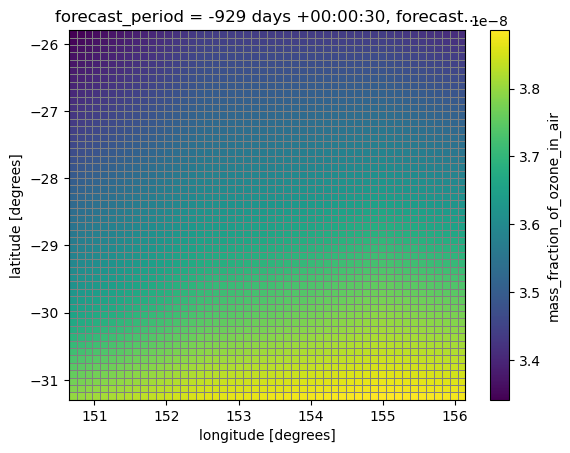

In [97]:
xr.DataArray.from_iris(ozone[0]).plot(edgecolor='grey',linewidth=0.5)

Let's now examine the aerosol climatologies:

- `<Region>_<Resolution>_ancil_ocff` produces dry aerosol climatologies of organic carbon from fossil fuels and is stored in `qrclim.ocff`.
- `<Region>_<Resolution>_ancil_sulp` produces dry aerosol climatologies of sulfate and is stored in `qrclim.sulp`.
- `<Region>_<Resolution>_ancil_biog` produces aerosol climatologies of biogenic Non-Methane Volatile Organic Compounds and is stored in `qrclim.biog`.
- `<Region>_<Resolution>_ancil_blk` produces aerosol climatologies of black carbon and are stored in `qrclim.blck`.
- `<Region>_<Resolution>_ancil_biom` produces aerosol climatologies of fresh burning biomass and is stored in `qrclim.biom`.
- `<Region>_<Resolution>_ancil_sslt` produces aerosol climatologies of sea salt particles and is stored in `qrclim.sslt`.
- `<Region>_<Resolution>_ancil_dust` produces aerosol climatologies of dust and is stored in `qrclim.dust`.

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/iris/fileformats/rules.py:371: IrisUserWarning: Unable to create instance of HybridHeightFactory. The source data contains no field(s) for 'orography'.
  warnings.warn(
/jobfs/172902492.gadi-pbs/ipykernel_3151241/2672610593.py:11: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  xr.DataArray.from_iris(clim[0][0,0]).plot(ax=ax)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/pytho

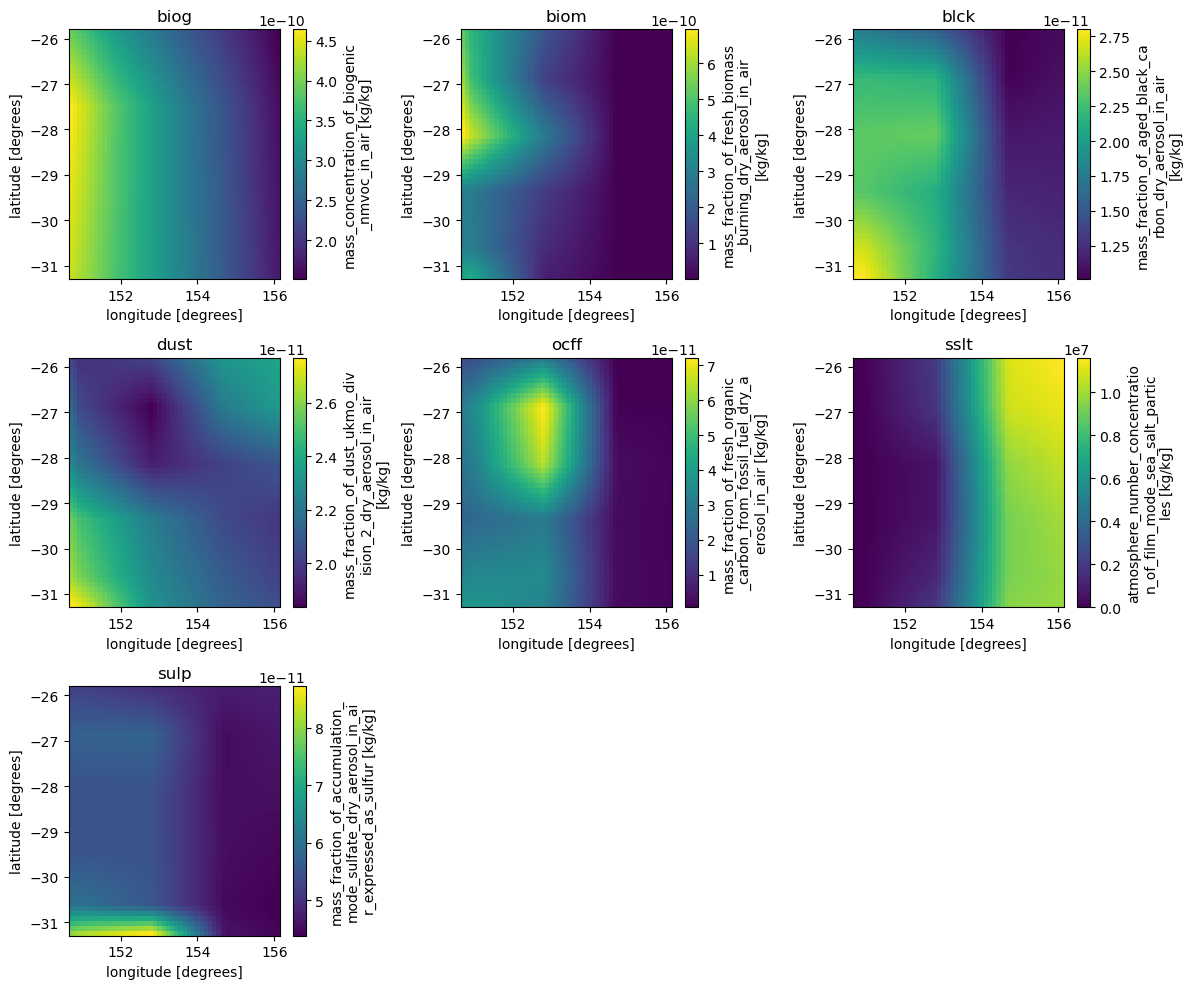

In [70]:
AERO_CLIMS = ["biog", "biom", "blck", "dust", "ocff", "sslt", "sulp"]

fig = plt.figure(figsize=(12,10))
num_rows=3
num_columns=3
Position=range(1,len(AERO_CLIMS)+1)
k=0
for CLIM in AERO_CLIMS:
    clim = iris.load( ANCIL_DIR / f'qrclim.{CLIM}')
    ax = fig.add_subplot(num_rows, num_columns, Position[k])
    xr.DataArray.from_iris(clim[0][0,0]).plot(ax=ax)
    ax.set_title(CLIM)
    k+=1
plt.tight_layout()

The remainings tasks are :
- `<Region>_<Resolution>_ancil_clim_sea` which produces climatology of ocean chlorophyll concentrations which are stored in `qrclim.sea`

In [71]:
sea, = iris.load( ANCIL_DIR / 'qrclim.sea')

/jobfs/172902492.gadi-pbs/ipykernel_3151241/3069948462.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  xr.DataArray.from_iris(sea[0]).plot(edgecolor='grey',linewidth=0.5)


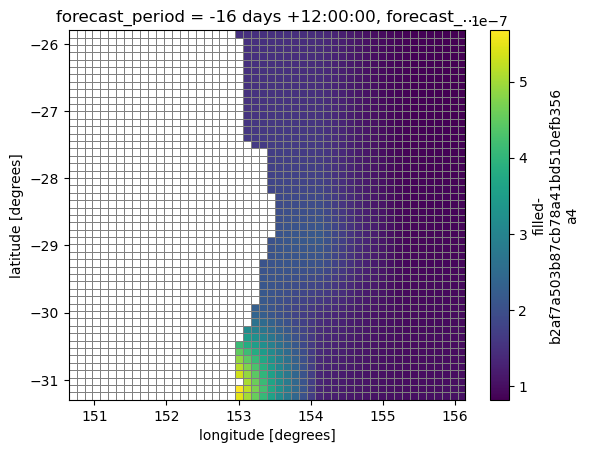

In [72]:
xr.DataArray.from_iris(sea[0]).plot(edgecolor='grey',linewidth=0.5)

- `<Region>_<Resolution>_ancil_lake` which regrids the global lake mask dataset and produces the local ancillary file `qrparm.lake`.  

In [7]:
global_lake_file = Path('/home/548/pag548/cylc-run/rCM3-ancil-suite/share/data/etc/ancil_master_ants//lake/ARClake/v2/qrdata.mask.nc')
global_lake = xr.load_dataset(global_lake_file)

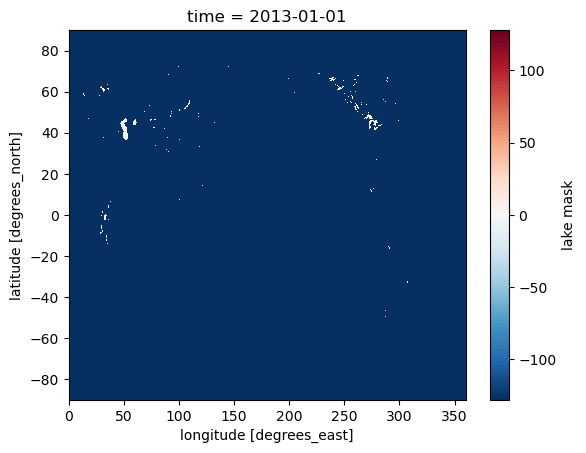

In [17]:
global_lake.lake_mask.plot()

In [2]:
lake, = iris.load( ANCIL_DIR / 'qrparm.lake')

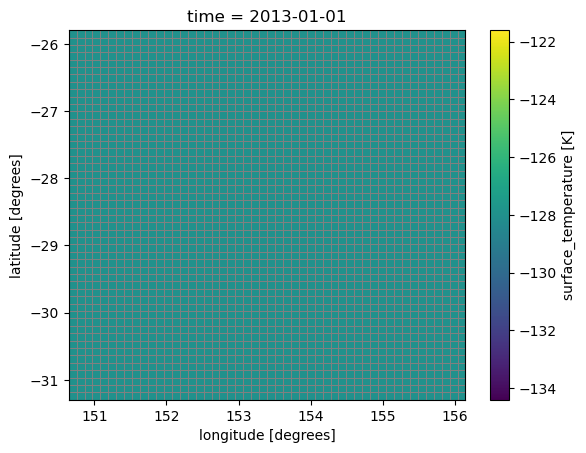

In [20]:
xr.DataArray.from_iris(lake).plot(edgecolor='grey',linewidth=0.5)

The global lake dataset identifies large inland lakes (e.g. Caspian Sea, The Great Lakes) and sets a mask value of -128 everywhere else

- `<Region>_<Resolution>_ancil_lct_postproc_moruses` performs a two-type urban fraction and urban morphology post-processor to implement the Met Office–Reading Urban Surface Exchange Scheme (MORUSES). The intermediate output file is `qrparm.MORUSES.morph`

In [21]:
moru = iris.load( ANCIL_DIR / 'qrparm.MORUSES.morph')

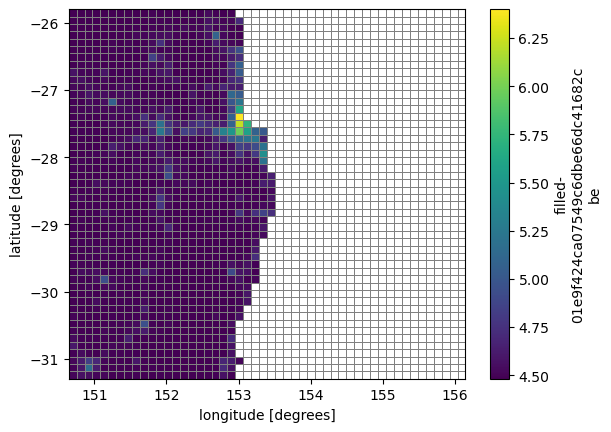

In [53]:
xr.DataArray.from_iris(moru[0]).plot(edgecolor='grey',linewidth=0.5)

- `<Region>_<Resolution>_ancil_lct_land` runs the application `app/ancil_snowfree_albedo/rose-app.conf`. The suite logic in `suite-runtime/ants.rc` states:
```
    [[{{ancil(regn, resln)}}_land]]
        # SW snow-free surface albedo.
        inherit = {{ancil(regn, resln)}},ANCIL_SNOWFREE_ALBEDO
```
and 
```
    [[ANCIL_SNOWFREE_ALBEDO]]
        inherit = ANCIL_ANTS, HOST_ANTS_MPP
        [[[environment]]]
            ROSE_TASK_APP=ancil_snowfree_albedo
```
The output of this task is `qrclim.land`

In [98]:
land = iris.load( ANCIL_DIR / 'qrclim.land')

/jobfs/177174656.gadi-pbs/ipykernel_1618406/2023900724.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  xr.DataArray.from_iris(land[0][0]).plot(edgecolor='grey',linewidth=0.5)


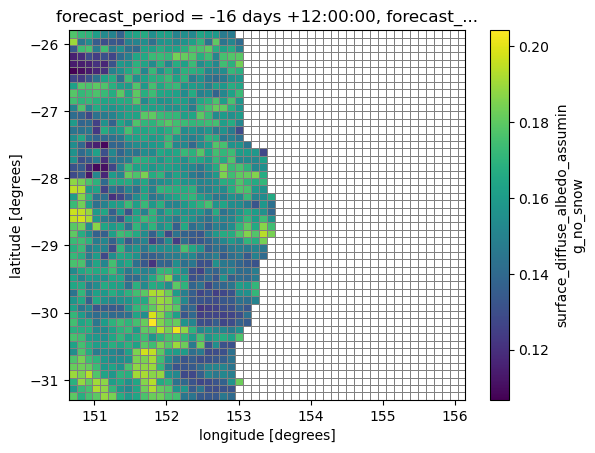

In [99]:
xr.DataArray.from_iris(land[0][0]).plot(edgecolor='grey',linewidth=0.5)

## How do I check the validity of the ancillaries?

Now run the notebook 'Check_UM_ancils.ipynb' to confirm:
- Your ancillaries generated with the python `ants` and Fortran `cap` workflows have the same co-ordinates (to within reasonable precision).
- There are no empty (or NaN values) over the land area defined by the land-sea mask